In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['svg.fonttype'] = 'none'

## load layouts and quantification files

In [3]:
Experiment1Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/PTEFB_SIRNA/250822_PTEFB_SIRNA/METADATA/250822_PTEFB_SIRNA.csv")
Experiment2Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/PTEFB_SIRNA/251010_PTEFB_SIRNA/METADATA/251010_PTEFB_SIRNA.csv")

In [4]:
Experiment1_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250822_PTEFB_SIRNA/20250826_170901_845/QUANTIFICATION")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))

Experiment2_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251010_PTEFB_SIRNA/20251014_164710_813/QUANTIFICATION")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))

len(Experiment1_Quantification_Files), len(Experiment2_Quantification_Files)

(954, 960)

In [5]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell['fov'] = fovs

Experiment1_Intensities = pd.DataFrame({
    "WELL" : Experiment1_PerCell['well'],
    "IF_647_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_647'],
    "IF_488_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_PerCell['Nuclei_area']
})

100%|█████████████████████████████████████████| 954/954 [00:13<00:00, 69.08it/s]


In [6]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment2_PerCell['fov'] = fovs

Experiment2_Intensities = pd.DataFrame({
    "WELL" : Experiment2_PerCell['well'],
    "IF_647_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_647'],
    "IF_488_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 960/960 [00:05<00:00, 189.44it/s]


In [7]:
CountsByWell1 = Experiment1_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = Experiment1_Intensities.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell1, how = 'left')
IntensitiesByWell_Experiment1['EXPERIMENT'] = '250822_PTEFB_SIRNA'

CountsByWell2 = Experiment2_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = Experiment2_Intensities.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell2, how = 'left')
IntensitiesByWell_Experiment2['EXPERIMENT'] = '251010_PTEFB_SIRNA'

In [8]:
IntensitiesByWell_Experiment1.to_csv('250822_PTEFB_SIRNA/250822_PTEFB_SIRNA_well_means.csv')
IntensitiesByWell_Experiment2.to_csv('251010_PTEFB_SIRNA/251010_PTEFB_SIRNA_well_means.csv')

## examine data per experiment

<Axes: ylabel='TotalNumberCells'>

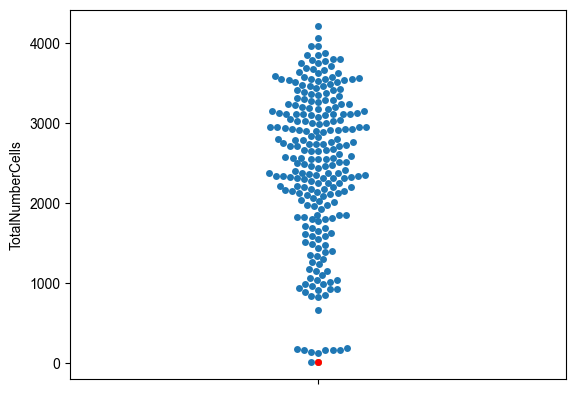

In [9]:
sns.swarmplot(IntensitiesByWell_Experiment1.TotalNumberCells)
sns.swarmplot(IntensitiesByWell_Experiment1.query('WELL == "N06"').TotalNumberCells, color = 'orange')
sns.swarmplot(IntensitiesByWell_Experiment1.query('WELL == "H06"').TotalNumberCells, color = 'red')

In [10]:
## exclude N06 and H06 in Experiment1, due to very low cell number
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('WELL != "N06" & WELL != "H06"')

In [11]:
sirnas = ['No transfection', 
 'Scrambled', 
 'HEXIM1 #1', 
 'HEXIM1 #2',
 'HEXIM1 #3', 
 'HEXIM2 #1', 
 'HEXIM2 #2', 
 'HEXIM2 #3', 
 'LARP7 #1',
 'LARP7 #2', 
 'LARP7 #3', 
 'HEXIM1 pool', 
 'HEXIM2 pool', 
 'LARP7 pool',
 'HEXIM1 pool + HEXIM2 pool', 
 'HEXIM2 pool + LARP7 pool',
 'HEXIM1 pool + LARP7 pool', 
 'INTS8 pool', 
 'SPT5 pool', 
 'POLR2B']

sirnas_colour = ['Control', 
 'Control', 
 'HEXIM1', 
 'HEXIM1',
 'HEXIM1', 
 'HEXIM2', 
 'HEXIM2', 
 'HEXIM2', 
 'LARP7',
 'LARP7', 
 'LARP7', 
 'HEXIM1', 
 'HEXIM2', 
 'LARP7',
 'HEXIM1 pool + HEXIM2 pool', 
 'HEXIM2 pool + LARP7 pool',
 'HEXIM1 pool + LARP7 pool', 
 'INTS8 pool', 
 'SPT5 pool', 
 'POLR2B']

IntensitiesByWell_Experiment1['SIRNA_HUE'] = IntensitiesByWell_Experiment1['SIRNA'].map(dict(zip(sirnas,sirnas_colour)))
IntensitiesByWell_Experiment2['SIRNA_HUE'] = IntensitiesByWell_Experiment2['SIRNA'].map(dict(zip(sirnas,sirnas_colour)))


sirnas_order = ['No transfection', 
                'Scrambled', 
                'HEXIM1 #1', 
                 'HEXIM1 #2',
                 'HEXIM1 #3',
                'HEXIM1 pool',
                 'HEXIM2 #1', 
                 'HEXIM2 #2', 
                 'HEXIM2 #3', 
                  'HEXIM2 pool', 
                 'LARP7 #1',
                 'LARP7 #2', 
                 'LARP7 #3', 
                 'LARP7 pool',
                 'HEXIM1 pool + HEXIM2 pool', 
                 'HEXIM2 pool + LARP7 pool',
                 'HEXIM1 pool + LARP7 pool', 
                 'INTS8 pool', 
                 'SPT5 pool', 
                 'POLR2B']

sirna_hues_order = list(np.unique(sirnas_colour))

(0.0, 8000.0)

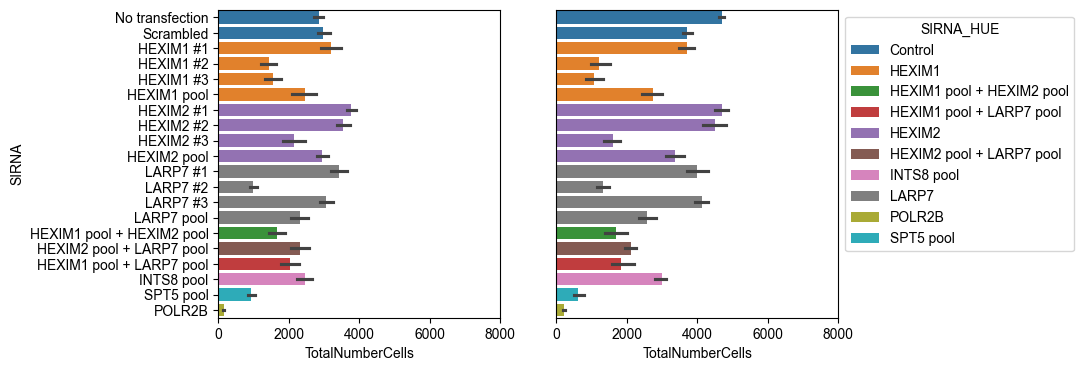

In [12]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(IntensitiesByWell_Experiment1,
            x = 'TotalNumberCells',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(IntensitiesByWell_Experiment2,
            x = 'TotalNumberCells',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,8000)
a[1].set_xlim(0,8000)

(0.0, 2000.0)

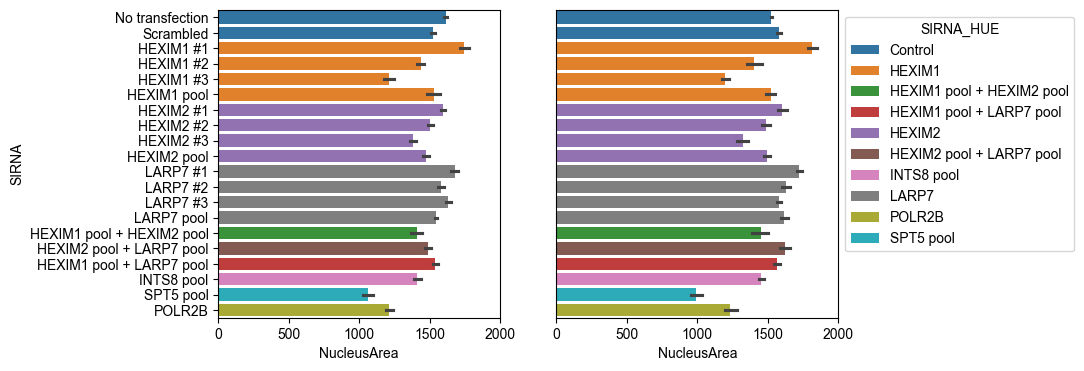

In [13]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(IntensitiesByWell_Experiment1,
            x = 'NucleusArea',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(IntensitiesByWell_Experiment2,
            x = 'NucleusArea',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,2000)
a[1].set_xlim(0,2000)

## normalise IF intensity per primary and compare across experiments

### pSer2 Pol II (3E10)

In [14]:
Experiment1_3E10_ByWell = IntensitiesByWell_Experiment1.query('PRIMARY_1 == "pSer2 3E10"')
Experiment2_3E10_ByWell = IntensitiesByWell_Experiment2.query('PRIMARY_1 == "pSer2 3E10"')

Experiment1_3E10_Zero = IntensitiesByWell_Experiment1.query('PRIMARY_1 == "No primary" & SECONDARY_1 == "Goat anti-rat Alexa647"')['IF_647_Intensity'].mean()
Experiment2_3E10_Zero = IntensitiesByWell_Experiment2.query('PRIMARY_1 == "No primary" & SECONDARY_1 == "Goat anti-rat Alexa647"')['IF_647_Intensity'].mean()

Experiment1_3E10_ByWell['IF_647_Intensity_BGS'] = Experiment1_3E10_ByWell['IF_647_Intensity'] - Experiment1_3E10_Zero
Experiment2_3E10_ByWell['IF_647_Intensity_BGS'] = Experiment2_3E10_ByWell['IF_647_Intensity'] - Experiment2_3E10_Zero

Experiment1_3E10_NT_Mean = Experiment1_3E10_ByWell.query('SIRNA == "No transfection"')['IF_647_Intensity_BGS'].mean()
Experiment2_3E10_NT_Mean = Experiment2_3E10_ByWell.query('SIRNA == "No transfection"')['IF_647_Intensity_BGS'].mean()

Experiment1_3E10_ByWell['IF_647_FC'] = Experiment1_3E10_ByWell['IF_647_Intensity_BGS'] / Experiment1_3E10_NT_Mean
Experiment2_3E10_ByWell['IF_647_FC'] = Experiment2_3E10_ByWell['IF_647_Intensity_BGS'] / Experiment2_3E10_NT_Mean

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_28844/4015973927.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Experiment1_3E10_ByWell['IF_647_Intensity_BGS'] = Experiment1_3E10_ByWell['IF_647_Intensity'] - Experiment1_3E10_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_28844/4015973927.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Experiment2_3E10_ByWell['IF_647_Intensity_BGS'] = Experiment2_3E10_ByWell['IF_647_Intensity'] - Experiment2_3E10_Zero
/var/folders/fc/5gv1

(0.0, 3500.0)

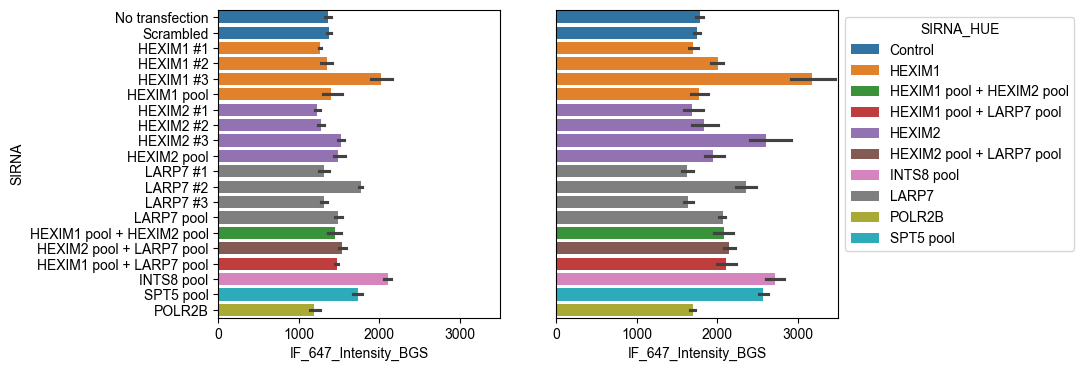

In [15]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(Experiment1_3E10_ByWell,
            x = 'IF_647_Intensity_BGS',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(Experiment2_3E10_ByWell,
            x = 'IF_647_Intensity_BGS',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,3500)
a[1].set_xlim(0,3500)

(0.0, 2.0)

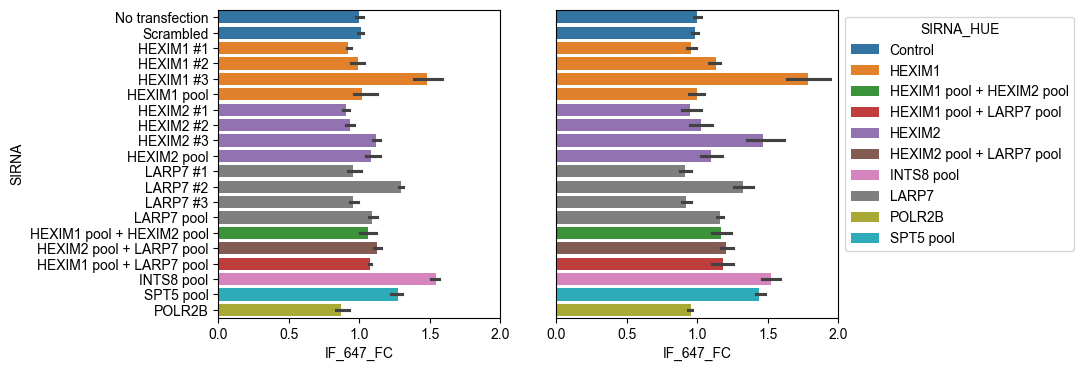

In [16]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(Experiment1_3E10_ByWell,
            x = 'IF_647_FC',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(Experiment2_3E10_ByWell,
            x = 'IF_647_FC',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,2)
a[1].set_xlim(0,2)

### Total Pol II F12

In [17]:
Experiment1_F12_ByWell = IntensitiesByWell_Experiment1.query('PRIMARY_1 == "Total Pol II F12"')
Experiment2_F12_ByWell = IntensitiesByWell_Experiment2.query('PRIMARY_1 == "Total Pol II F12"')

Experiment1_F12_Zero = IntensitiesByWell_Experiment1.query('PRIMARY_1 == "No primary" & SECONDARY_1 == "Goat anti-mouse Alexa647"')['IF_647_Intensity'].mean()
Experiment2_F12_Zero = IntensitiesByWell_Experiment2.query('PRIMARY_1 == "No primary" & SECONDARY_1 == "Goat anti-mouse Alexa647"')['IF_647_Intensity'].mean()

Experiment1_F12_ByWell['IF_647_Intensity_BGS'] = Experiment1_F12_ByWell['IF_647_Intensity'] - Experiment1_F12_Zero
Experiment2_F12_ByWell['IF_647_Intensity_BGS'] = Experiment2_F12_ByWell['IF_647_Intensity'] - Experiment2_F12_Zero

Experiment1_F12_NT_Mean = Experiment1_F12_ByWell.query('SIRNA == "No transfection"')['IF_647_Intensity_BGS'].mean()
Experiment2_F12_NT_Mean = Experiment2_F12_ByWell.query('SIRNA == "No transfection"')['IF_647_Intensity_BGS'].mean()

Experiment1_F12_ByWell['IF_647_FC'] = Experiment1_F12_ByWell['IF_647_Intensity_BGS'] / Experiment1_F12_NT_Mean
Experiment2_F12_ByWell['IF_647_FC'] = Experiment2_F12_ByWell['IF_647_Intensity_BGS'] / Experiment2_F12_NT_Mean

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_28844/1370325036.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Experiment1_F12_ByWell['IF_647_Intensity_BGS'] = Experiment1_F12_ByWell['IF_647_Intensity'] - Experiment1_F12_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_28844/1370325036.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Experiment2_F12_ByWell['IF_647_Intensity_BGS'] = Experiment2_F12_ByWell['IF_647_Intensity'] - Experiment2_F12_Zero
/var/folders/fc/5gv13_yd4d

(0.0, 3500.0)

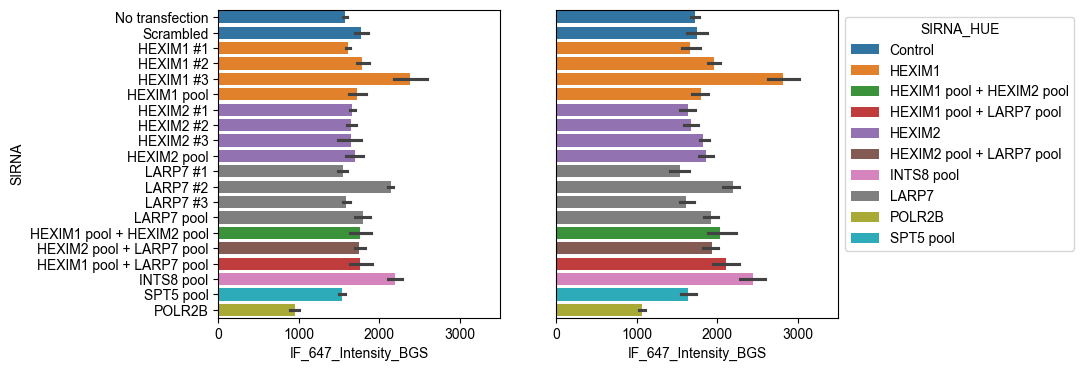

In [18]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(Experiment1_F12_ByWell,
            x = 'IF_647_Intensity_BGS',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(Experiment2_F12_ByWell,
            x = 'IF_647_Intensity_BGS',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')


a[0].set_xlim(0,3500)
a[1].set_xlim(0,3500)

(0.0, 2.0)

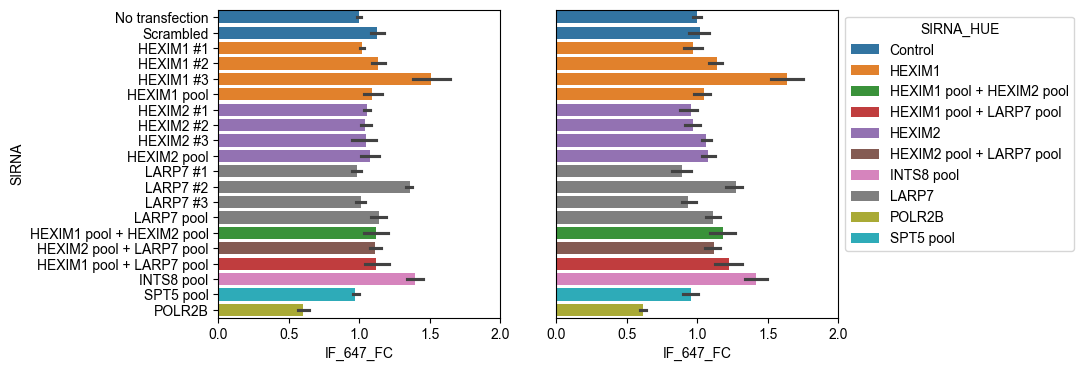

In [19]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(Experiment1_F12_ByWell,
            x = 'IF_647_FC',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE',  hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])
h.get_legend().remove()

h = sns.barplot(Experiment2_F12_ByWell,
            x = 'IF_647_FC',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE',  hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,2)
a[1].set_xlim(0,2)


### CDK9

In [20]:
IntensitiesByWell_Experiment2.query('PRIMARY_1 == "No primary" & SECONDARY_2 == "Goat anti-rabbit Alexa488+"')['IF_488_Intensity'].mean()

970.4525617410577

In [21]:
Experiment1_CDK9_ByWell = IntensitiesByWell_Experiment1.query('PRIMARY_2 == "CDK9"')
Experiment2_CDK9_ByWell = IntensitiesByWell_Experiment2.query('PRIMARY_2 == "CDK9"')

Experiment1_CDK9_Zero = IntensitiesByWell_Experiment1.query('PRIMARY_2 == "No primary" & SECONDARY_2 == "Goat anti-rabbit Alexa488+"')['IF_488_Intensity'].mean()
Experiment2_CDK9_Zero = IntensitiesByWell_Experiment2.query('PRIMARY_2 == "No primary" & SECONDARY_2 == "Goat anti-rabbit Alexa488+"')['IF_488_Intensity'].mean()

Experiment1_CDK9_ByWell['IF_488_Intensity_BGS'] = Experiment1_CDK9_ByWell['IF_488_Intensity'] - Experiment1_CDK9_Zero
Experiment2_CDK9_ByWell['IF_488_Intensity_BGS'] = Experiment2_CDK9_ByWell['IF_488_Intensity'] - Experiment2_CDK9_Zero

Experiment1_CDK9_NT_Mean = Experiment1_CDK9_ByWell.query('SIRNA == "No transfection"')['IF_488_Intensity_BGS'].mean()
Experiment2_CDK9_NT_Mean = Experiment2_CDK9_ByWell.query('SIRNA == "No transfection"')['IF_488_Intensity_BGS'].mean()

Experiment1_CDK9_ByWell['IF_488_FC'] = Experiment1_CDK9_ByWell['IF_488_Intensity_BGS'] / Experiment1_CDK9_NT_Mean
Experiment2_CDK9_ByWell['IF_488_FC'] = Experiment2_CDK9_ByWell['IF_488_Intensity_BGS'] / Experiment2_CDK9_NT_Mean

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_28844/4212049056.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Experiment1_CDK9_ByWell['IF_488_Intensity_BGS'] = Experiment1_CDK9_ByWell['IF_488_Intensity'] - Experiment1_CDK9_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_28844/4212049056.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Experiment2_CDK9_ByWell['IF_488_Intensity_BGS'] = Experiment2_CDK9_ByWell['IF_488_Intensity'] - Experiment2_CDK9_Zero
/var/folders/fc/5gv1

(0.0, 2500.0)

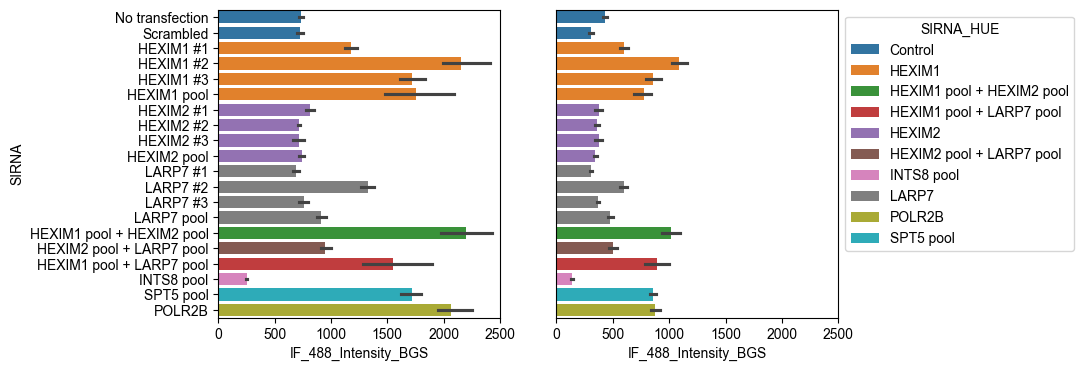

In [22]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(Experiment1_CDK9_ByWell,
            x = 'IF_488_Intensity_BGS',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(Experiment2_CDK9_ByWell,
            x = 'IF_488_Intensity_BGS',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,2500)
a[1].set_xlim(0,2500)

(0.0, 4.0)

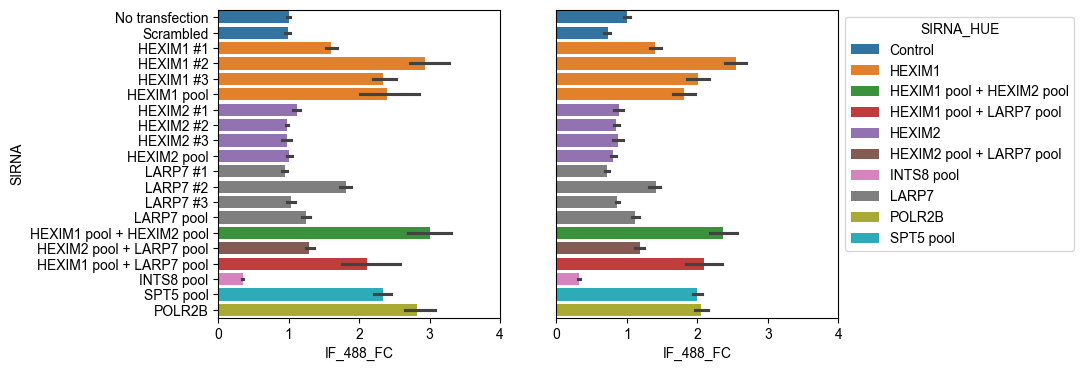

In [23]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(Experiment1_CDK9_ByWell,
            x = 'IF_488_FC',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE',  hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(Experiment2_CDK9_ByWell,
            x = 'IF_488_FC',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE',  hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,4)
a[1].set_xlim(0,4)

### HEXIM1

In [24]:
Experiment1_HEXIM1_ByWell = IntensitiesByWell_Experiment1.query('PRIMARY_2 == "HEXIM1"')
Experiment2_HEXIM1_ByWell = IntensitiesByWell_Experiment2.query('PRIMARY_2 == "HEXIM1"')

Experiment1_HEXIM1_Zero = IntensitiesByWell_Experiment1.query('PRIMARY_2 == "No primary" & SECONDARY_2 == "Goat anti-rabbit Alexa488+"')['IF_488_Intensity'].mean()
Experiment2_HEXIM1_Zero = IntensitiesByWell_Experiment2.query('PRIMARY_2 == "No primary" & SECONDARY_2 == "Goat anti-rabbit Alexa488+"')['IF_488_Intensity'].mean()

Experiment1_HEXIM1_ByWell['IF_488_Intensity_BGS'] = Experiment1_HEXIM1_ByWell['IF_488_Intensity'] - Experiment1_HEXIM1_Zero
Experiment2_HEXIM1_ByWell['IF_488_Intensity_BGS'] = Experiment2_HEXIM1_ByWell['IF_488_Intensity'] - Experiment2_HEXIM1_Zero

Experiment1_HEXIM1_NT_Mean = Experiment1_HEXIM1_ByWell.query('SIRNA == "No transfection"')['IF_488_Intensity_BGS'].mean()
Experiment2_HEXIM1_NT_Mean = Experiment2_HEXIM1_ByWell.query('SIRNA == "No transfection"')['IF_488_Intensity_BGS'].mean()

Experiment1_HEXIM1_ByWell['IF_488_FC'] = Experiment1_HEXIM1_ByWell['IF_488_Intensity_BGS'] / Experiment1_HEXIM1_NT_Mean
Experiment2_HEXIM1_ByWell['IF_488_FC'] = Experiment2_HEXIM1_ByWell['IF_488_Intensity_BGS'] / Experiment2_HEXIM1_NT_Mean

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_28844/3600437352.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Experiment1_HEXIM1_ByWell['IF_488_Intensity_BGS'] = Experiment1_HEXIM1_ByWell['IF_488_Intensity'] - Experiment1_HEXIM1_Zero
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_28844/3600437352.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Experiment2_HEXIM1_ByWell['IF_488_Intensity_BGS'] = Experiment2_HEXIM1_ByWell['IF_488_Intensity'] - Experiment2_HEXIM1_Zero
/var/fol

(0.0, 4000.0)

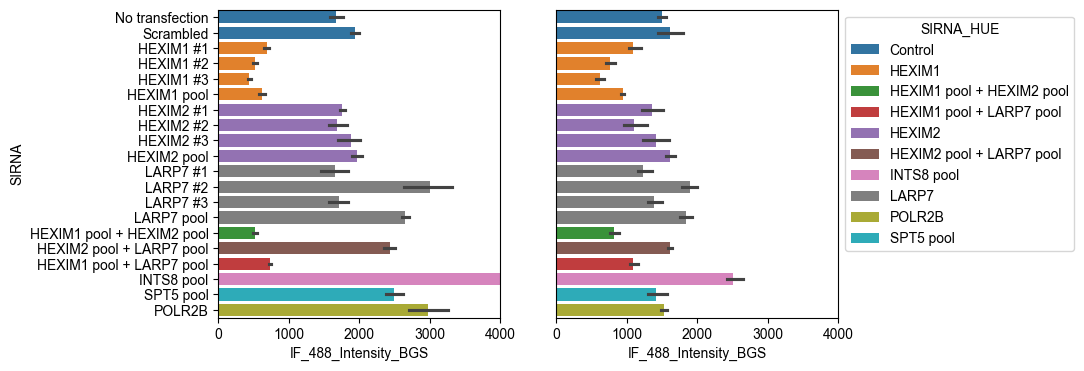

In [25]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(Experiment1_HEXIM1_ByWell,
            x = 'IF_488_Intensity_BGS',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(Experiment2_HEXIM1_ByWell,
            x = 'IF_488_Intensity_BGS',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE', hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])

sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,4000)
a[1].set_xlim(0,4000)

(0.0, 4.0)

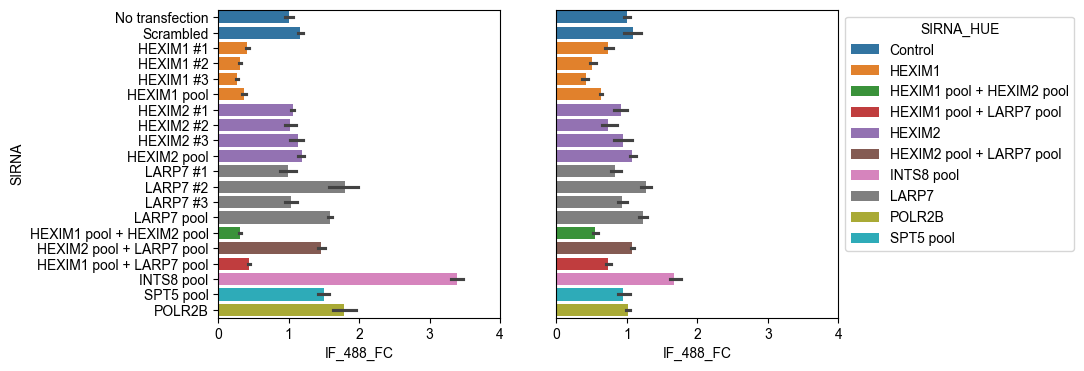

In [26]:
f, a = plt.subplots(ncols = 2, figsize = (8,4))

h = sns.barplot(Experiment1_HEXIM1_ByWell,
            x = 'IF_488_FC',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE',  hue_order = sirna_hues_order,
            dodge = False,
                ax = a[0])

h.get_legend().remove()

h = sns.barplot(Experiment2_HEXIM1_ByWell,
            x = 'IF_488_FC',
            y = 'SIRNA', order = sirnas_order,
                hue = 'SIRNA_HUE',  hue_order = sirna_hues_order,
            dodge = False,
                ax = a[1])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

a[1].get_yaxis().set_ticks([])
a[1].set_ylabel('')

a[0].set_xlim(0,4)
a[1].set_xlim(0,4)

## merge experiments and plot summary data

In [27]:
pSer2_ByWell = pd.concat([Experiment1_3E10_ByWell, Experiment2_3E10_ByWell])
TotalPol2_ByWell = pd.concat([Experiment1_F12_ByWell, Experiment2_F12_ByWell])
HEXIM1_ByWell = pd.concat([Experiment1_HEXIM1_ByWell, Experiment2_HEXIM1_ByWell])
CDK9_ByWell = pd.concat([Experiment1_CDK9_ByWell, Experiment2_CDK9_ByWell])

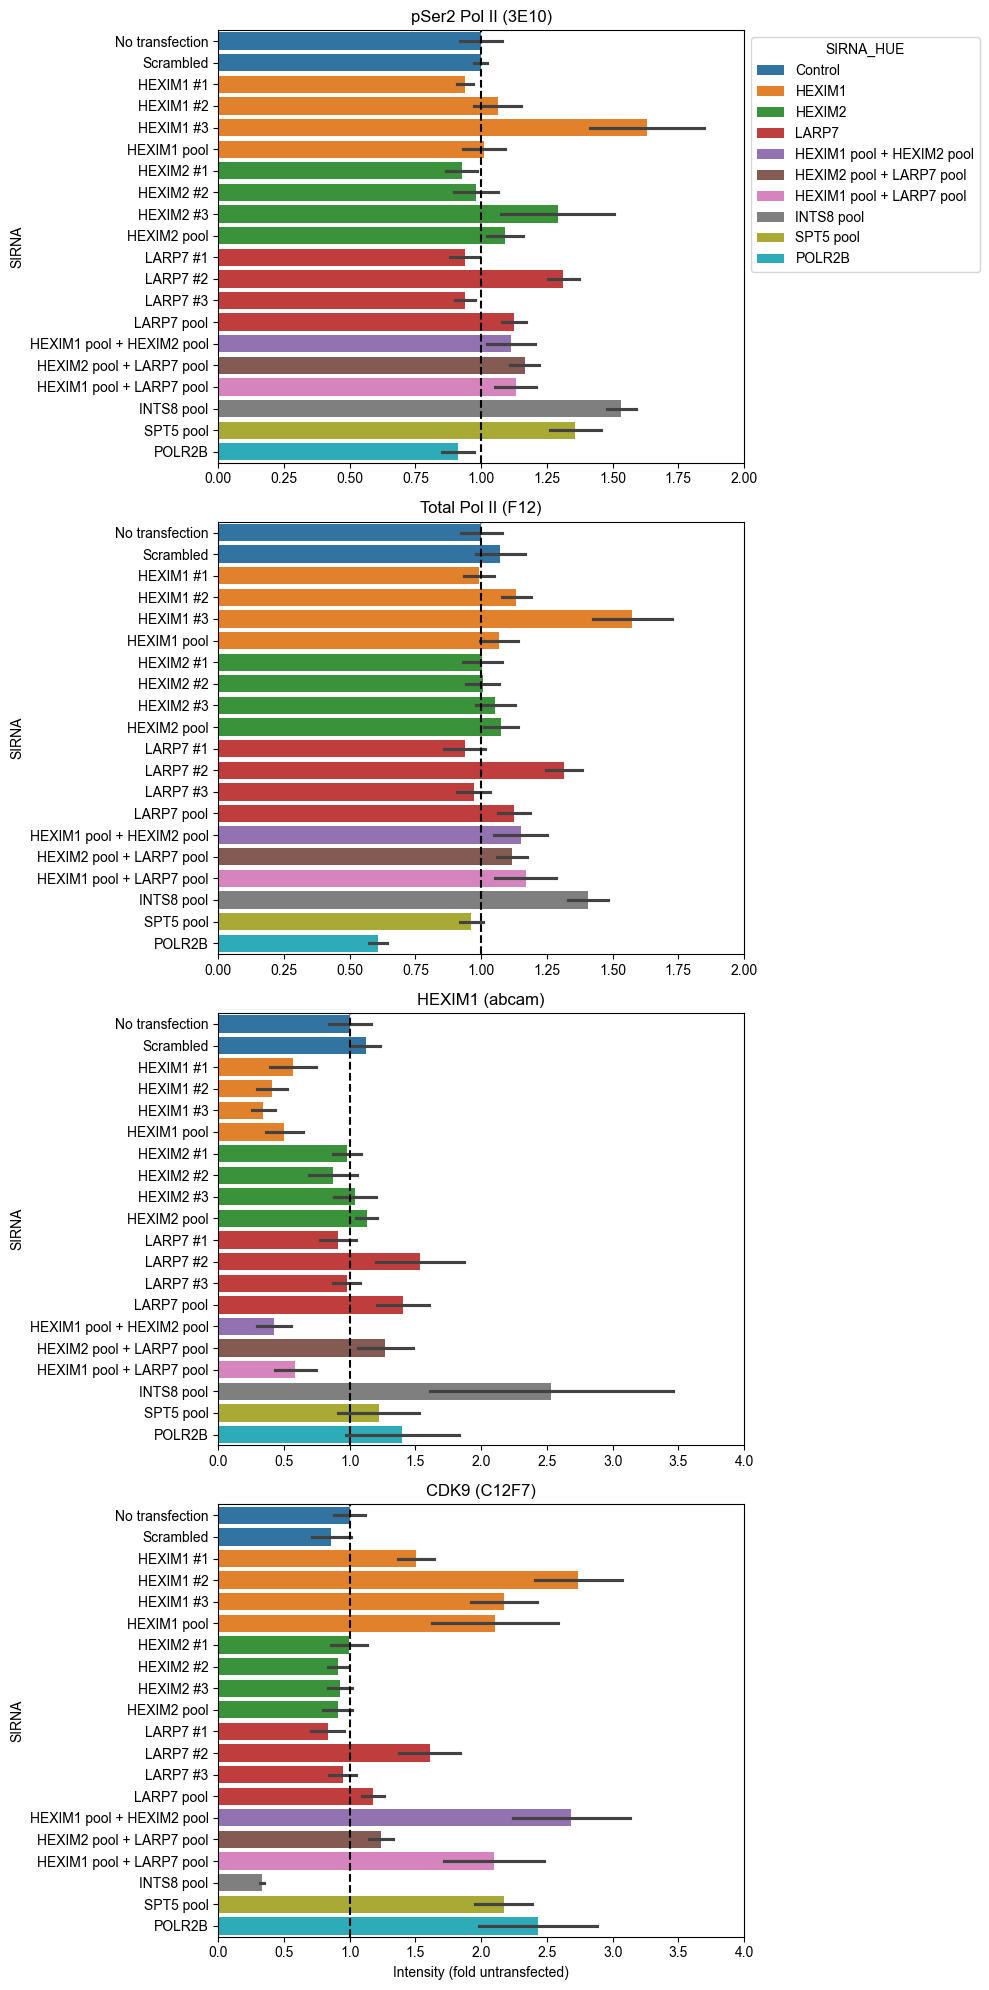

In [28]:
f, a = plt.subplots(nrows = 4, figsize = (10,20))

h = sns.barplot(pSer2_ByWell,
                x = 'IF_647_FC',
                y = 'SIRNA', order = sirnas_order,
                errorbar = 'sd',
                hue = 'SIRNA_HUE',
                dodge = False,
                ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.barplot(TotalPol2_ByWell,
                x = 'IF_647_FC',
                y = 'SIRNA', order = sirnas_order,
                errorbar = 'sd',
                hue = 'SIRNA_HUE',
                dodge = False,
                ax = a[1])
h.get_legend().remove()

h = sns.barplot(HEXIM1_ByWell,
                x = 'IF_488_FC',
                y = 'SIRNA', order = sirnas_order,
                errorbar = 'sd',
                hue = 'SIRNA_HUE',
                dodge = False,
                ax = a[2])
h.get_legend().remove()

h = sns.barplot(CDK9_ByWell,
                x = 'IF_488_FC',
                y = 'SIRNA', order = sirnas_order,
                errorbar = 'sd',
                hue = 'SIRNA_HUE',
                dodge = False,
                ax = a[3])
h.get_legend().remove()

titles = ['pSer2 Pol II (3E10)', 'Total Pol II (F12)', 'HEXIM1 (abcam)', 'CDK9 (C12F7)']
for i in range(4):
    a[i].set_title(titles[i])
    a[i].axvline(1, color = 'black', linestyle = '--')
    
for i in range(3):
    a[i].set_xlabel('')

a[3].set_xlabel('Intensity (fold untransfected)')

a[0].set_xlim(0,2)
a[1].set_xlim(0,2)
a[2].set_xlim(0,4)
a[3].set_xlim(0,4)

plt.tight_layout()

In [29]:
sirnas_pools_only = ['No transfection',
                     'Scrambled',
                     'HEXIM1 pool',
                     'HEXIM2 pool',
                     'LARP7 pool',
                     'HEXIM1 pool + HEXIM2 pool',
                     'HEXIM2 pool + LARP7 pool',
                     'HEXIM1 pool + LARP7 pool',
                     'INTS8 pool',
                     'SPT5 pool',
                     'POLR2B']

In [30]:
pSer2_ByWell = pSer2_ByWell.reset_index()
TotalPol2_ByWell = TotalPol2_ByWell.reset_index()
HEXIM1_ByWell = HEXIM1_ByWell.reset_index()
CDK9_ByWell = CDK9_ByWell.reset_index()

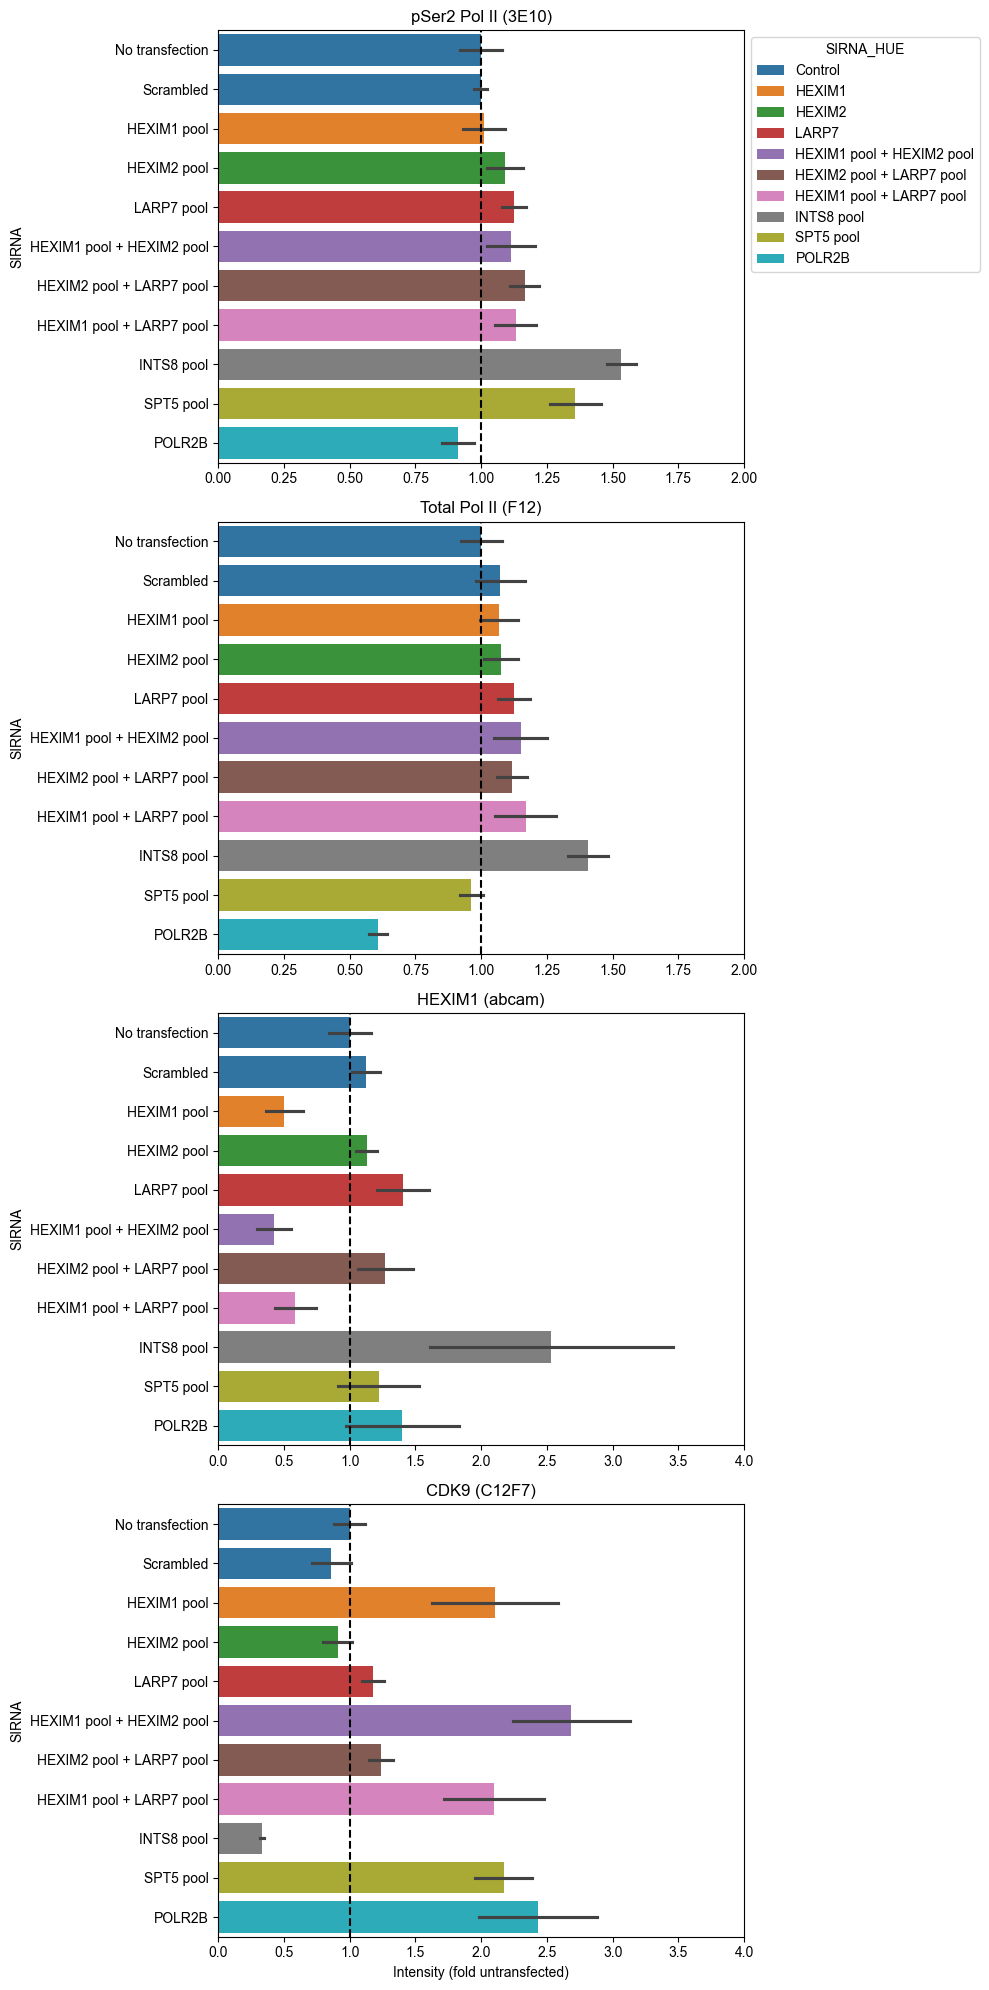

In [31]:
f, a = plt.subplots(nrows = 4, figsize = (10,20))

h = sns.barplot(pSer2_ByWell.reset_index(),
                x = 'IF_647_FC',
                y = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE',
                dodge = False,
                ax = a[0])
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

h = sns.barplot(TotalPol2_ByWell,
                x = 'IF_647_FC',
                y = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE',
                dodge = False,
                ax = a[1])
h.get_legend().remove()

h = sns.barplot(HEXIM1_ByWell,
                x = 'IF_488_FC',
                y = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE',
                dodge = False,
                ax = a[2])
h.get_legend().remove()

h = sns.barplot(CDK9_ByWell,
                x = 'IF_488_FC',
                y = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE',
                dodge = False,
                ax = a[3])
h.get_legend().remove()

titles = ['pSer2 Pol II (3E10)', 'Total Pol II (F12)', 'HEXIM1 (abcam)', 'CDK9 (C12F7)']
for i in range(4):
    a[i].set_title(titles[i])
    a[i].axvline(1, color = 'black', linestyle = '--')
    
for i in range(3):
    a[i].set_xlabel('')

a[3].set_xlabel('Intensity (fold untransfected)')

a[0].set_xlim(0,2)
a[1].set_xlim(0,2)
a[2].set_xlim(0,4)
a[3].set_xlim(0,4)

plt.tight_layout()

# Plots for manuscript

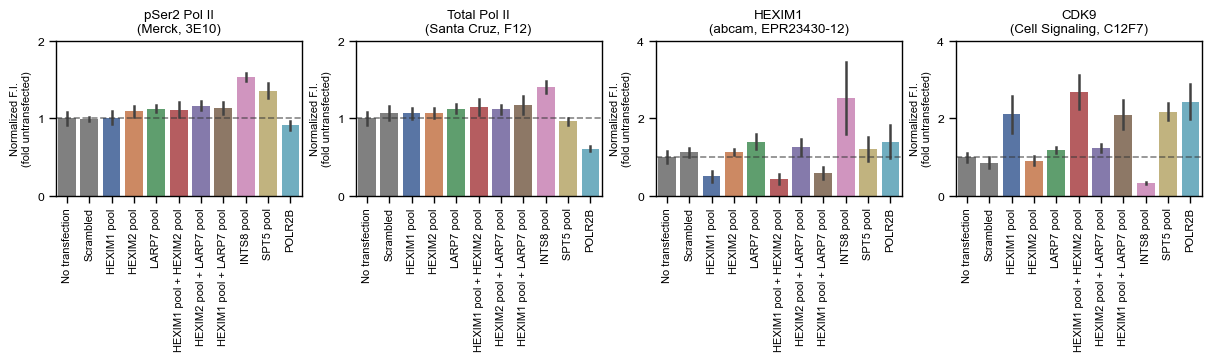

In [32]:
sns.set_context('paper')

pal = sns.color_palette('deep')[:10]
pal.insert(0, 'grey')
pal.pop(8)
pal = sns.color_palette(pal)

f, a = plt.subplots(ncols = 4, figsize = (12,3.5), layout = 'constrained')

h = sns.barplot(pSer2_ByWell,
                y = 'IF_647_FC',
                x = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE', palette = pal,
                dodge = False,
                ax = a[0])
h.get_legend().remove()

h = sns.barplot(TotalPol2_ByWell,
                y = 'IF_647_FC',
                x = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE', palette = pal,
                dodge = False,
                ax = a[1])
h.get_legend().remove()

h = sns.barplot(HEXIM1_ByWell,
                y = 'IF_488_FC',
                x = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE', palette = pal,
                dodge = False,
                ax = a[2])
h.get_legend().remove()

h = sns.barplot(CDK9_ByWell,
                y = 'IF_488_FC',
                x = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE', palette = pal,
                dodge = False,
                ax = a[3])
h.get_legend().remove()

a[0].set_title('pSer2 Pol II\n(Merck, 3E10)')
a[1].set_title('Total Pol II\n(Santa Cruz, F12)')
a[2].set_title('HEXIM1\n(abcam, EPR23430-12)')
a[3].set_title('CDK9\n(Cell Signaling, C12F7)')

a[0].set_ylim(0,2)
a[0].set_yticks(np.linspace(0,2,3))
a[1].set_ylim(0,2)
a[1].set_yticks(np.linspace(0,2,3))
a[2].set_ylim(0,4)
a[2].set_yticks(np.linspace(0,4,3))
a[3].set_ylim(0,4)
a[3].set_yticks(np.linspace(0,4,3))
    

for i in range(4):
    a[i].tick_params(axis = 'x', rotation = 90, labelsize = 8)
    a[i].set_ylabel('Normalized F.I.\n(fold untransfected)', fontsize = 8)
    a[i].axhline(1, linestyle = '--', color = 'xkcd:dark grey', alpha = 0.6)
    a[i].set_xlabel('')

plt.savefig('PTEFB_SIRNA_Pools.svg')

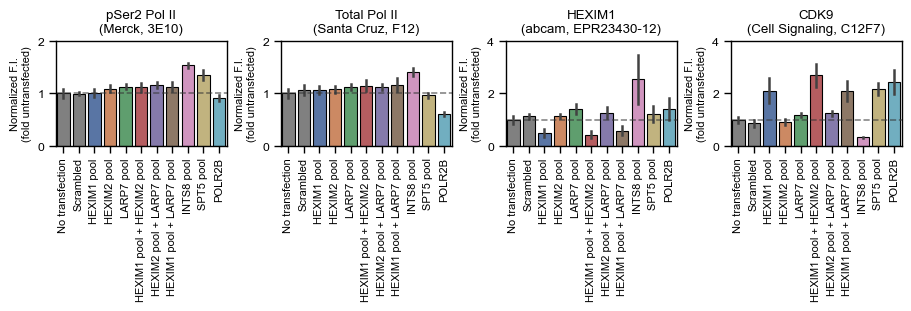

In [33]:
sns.set_context('paper')

pal = sns.color_palette('deep')[:10]
pal.insert(0, 'grey')
pal.pop(8)
pal = sns.color_palette(pal)

f, a = plt.subplots(ncols = 4, figsize = (9,3), layout = 'constrained')

h = sns.barplot(pSer2_ByWell,
                y = 'IF_647_FC',
                x = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE', palette = pal,
                edgecolor = 'black',
                dodge = False,
                ax = a[0])
h.get_legend().remove()

h = sns.barplot(TotalPol2_ByWell,
                y = 'IF_647_FC',
                x = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE', palette = pal,
                edgecolor = 'black',
                dodge = False,
                ax = a[1])
h.get_legend().remove()

h = sns.barplot(HEXIM1_ByWell,
                y = 'IF_488_FC',
                x = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE', palette = pal,
                edgecolor = 'black',
                dodge = False,
                ax = a[2])
h.get_legend().remove()

h = sns.barplot(CDK9_ByWell,
                y = 'IF_488_FC',
                x = 'SIRNA', order = sirnas_pools_only,
                errorbar = 'sd',
                hue = 'SIRNA_HUE', palette = pal,
                edgecolor = 'black',
                dodge = False,
                ax = a[3])
h.get_legend().remove()

a[0].set_title('pSer2 Pol II\n(Merck, 3E10)')
a[1].set_title('Total Pol II\n(Santa Cruz, F12)')
a[2].set_title('HEXIM1\n(abcam, EPR23430-12)')
a[3].set_title('CDK9\n(Cell Signaling, C12F7)')

a[0].set_ylim(0,2)
a[0].set_yticks(np.linspace(0,2,3))
a[1].set_ylim(0,2)
a[1].set_yticks(np.linspace(0,2,3))
a[2].set_ylim(0,4)
a[2].set_yticks(np.linspace(0,4,3))
a[3].set_ylim(0,4)
a[3].set_yticks(np.linspace(0,4,3))
    

for i in range(4):
    a[i].tick_params(axis = 'x', rotation = 90, labelsize = 8)
    a[i].set_ylabel('Normalized F.I.\n(fold untransfected)', fontsize = 8)
    a[i].axhline(1, linestyle = '--', color = 'xkcd:dark grey', alpha = 0.6)
    a[i].set_xlabel('')

plt.savefig('PTEFB_SIRNA_Pools.svg')

In [34]:
pSer2_ByWell.columns.tolist()

['index',
 'WELL',
 'IF_647_Intensity',
 'IF_488_Intensity',
 'DAPI_Intensity',
 'NucleusArea',
 'CELL',
 'SIRNA',
 'PRIMARY_1',
 'PRIMARY_2',
 'SECONDARY_1',
 'SECONDARY_2',
 'TotalNumberCells',
 'EXPERIMENT',
 'SIRNA_HUE',
 'IF_647_Intensity_BGS',
 'IF_647_FC']

In [36]:
PTEFB_SIRNA_well_summary_if_pser2polii_normalised = pSer2_ByWell[['EXPERIMENT','WELL','CELL','SIRNA','PRIMARY_1','PRIMARY_2','SECONDARY_1','SECONDARY_2', 'TotalNumberCells', 'IF_647_Intensity_BGS', 'IF_647_FC']]
PTEFB_SIRNA_well_summary_if_pser2polii_normalised.to_csv('PTEFB_SIRNA_well_summary_if_pser2polii_normalised.csv')

In [37]:
PTEFB_SIRNA_well_summary_if_totalpolii_normalised = TotalPol2_ByWell[['EXPERIMENT','WELL','CELL','SIRNA','PRIMARY_1','PRIMARY_2','SECONDARY_1','SECONDARY_2', 'TotalNumberCells', 'IF_647_Intensity_BGS', 'IF_647_FC']]
PTEFB_SIRNA_well_summary_if_totalpolii_normalised.to_csv('PTEFB_SIRNA_well_summary_if_totalpolii_normalised.csv')

In [40]:
PTEFB_SIRNA_well_summary_if_cdk9_normalised = CDK9_ByWell[['EXPERIMENT','WELL','CELL','SIRNA','PRIMARY_1','PRIMARY_2','SECONDARY_1','SECONDARY_2', 'TotalNumberCells','IF_488_Intensity_BGS', 'IF_488_FC']]
PTEFB_SIRNA_well_summary_if_cdk9_normalised.to_csv('PPTEFB_SIRNA_well_summary_if_cdk9_normalised.csv')

In [41]:
PTEFB_SIRNA_well_summary_if_hexim1_normalised = HEXIM1_ByWell[['EXPERIMENT','WELL','CELL','SIRNA','PRIMARY_1','PRIMARY_2','SECONDARY_1','SECONDARY_2', 'TotalNumberCells','IF_488_Intensity_BGS', 'IF_488_FC']]
PTEFB_SIRNA_well_summary_if_hexim1_normalised.to_csv('PPTEFB_SIRNA_well_summary_if_hexim1_normalised.csv')

In [34]:
## table of values

pd.DataFrame({'SIRNA': pSer2_ByWell[['SIRNA','IF_647_FC']].groupby('SIRNA').mean().reset_index().SIRNA,
  'FC': pSer2_ByWell[['SIRNA','IF_647_FC']].groupby('SIRNA').mean().reset_index().IF_647_FC,
  'SD' : pSer2_ByWell[['SIRNA','IF_647_FC']].groupby('SIRNA').std().reset_index().IF_647_FC})

,SIRNA,FC,SD
0,HEXIM1 #1,0.938351,0.031085
1,HEXIM1 #2,1.062450,0.088794
2,HEXIM1 #3,1.630581,0.217979
3,HEXIM1 pool,1.010620,0.079931
4,HEXIM1 pool + HEXIM2 pool,1.114189,0.092361
5,HEXIM1 pool + LARP7 pool,1.130951,0.078636
6,HEXIM2 #1,0.926130,0.059038
7,HEXIM2 #2,0.981507,0.083964
8,HEXIM2 #3,1.291149,0.214751
9,HEXIM2 pool,1.090877,0.069034
